In [1]:
import os
import sys
import json
import random
import time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from PIL import Image

# -- Repo root setup --
current_dir = os.path.abspath(os.getcwd())
REPO_ROOT = os.path.abspath(os.path.join(current_dir, '..'))
if REPO_ROOT not in sys.path:
    sys.path.append(REPO_ROOT)

# -- Custom module imports --
from models.feature_extractor import DenseNetFeatureExtractor
from models.meta_learner import MetricGenerator
from models.Triplet_Siamese_Similarity_Network import tDCBAM
from losses.triplet_loss import TripletLoss
from utils.model_evaluation import (
    compute_metrics, _plot_det_curve, _plot_far_frr,
    _plot_confusion_matrix, _plot_score_distribution, _plot_roc_curve
)
# Updated import: get_transforms replaces get_pretraining_transforms
from dataloader.tDCBAM_trainloader import get_transforms

/home/lawrence/workspace/thesis/thesis/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [2]:
def seed_everything(seed=42):
    """Apply deterministic seed across all random sources."""
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f" > [System] Seed set to: {seed}")


seed_everything(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" > [System] Device: {DEVICE}")
if torch.cuda.is_available():
    print(f" > [System] CUDA: {torch.cuda.get_device_name()}")

 > [System] Seed set to: 42
 > [System] Device: cuda
 > [System] CUDA: NVIDIA GeForce RTX 5080


In [3]:
# -- Input --
IMG_SIZE    = 224
INPUT_SHAPE = (IMG_SIZE, IMG_SIZE)

# -- DataLoader workers --
# Single constant used everywhere — change here to affect all loaders.
NUM_WORKERS = 4

# -- Step 1: Pretraining --
PRETRAIN_BATCH_SIZE   = 32
PRETRAIN_EPOCHS       = 30
PRETRAIN_PHASE1_EPOCHS = 7       # Frozen backbone epochs (CBAM + head only)
PRETRAIN_LR           = 1e-4
PRETRAIN_MARGIN       = 1.0

# -- Step 2: Meta-Training --
META_BATCH_SIZE    = 16
META_EPOCHS        = 70
META_PHASE1_EPOCHS = 20          # Frozen backbone epochs
META_LR_PHASE1     = 1e-3        # Phase 1: CBAM + MetricGenerator only
META_LR_BACKBONE   = 1e-5        # Phase 2: backbone (differential LR)
META_LR_HEAD       = 2e-4        # Phase 2: CBAM + head + MetricGenerator
META_WEIGHT_DECAY  = 1e-2        # CEDAR-specific weight decay

# -- Episodic protocol --
K_SHOT          = 1
N_QUERY_GENUINE = 1
N_QUERY_FORGERY = 1

# -- Model dimensions --
FEATURE_DIM   = 1024
EMBEDDING_DIM = 2048             # Concatenated: 1024 (support) + 1024 (query)

# -- Dataset & splits --
SPLIT_DIR    = os.path.join(REPO_ROOT, 'data', 'ratio_splits')
DATASET      = 'cedar'
DATASET_NAME = 'CEDAR'
SPLIT_RATIOS = ['70_15_15']

# -- Output directories --
CHECKPOINT_DIR = os.path.join(REPO_ROOT, 'checkpoints', 'proposed_splits')
NOTEBOOK_NAME  = 'proposed_cedar'
EVAL_DIR       = os.path.join(REPO_ROOT, 'model_evals', NOTEBOOK_NAME)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(EVAL_DIR, exist_ok=True)

print(f"[Config] Step 1 — Pretraining : {PRETRAIN_EPOCHS} epochs | margin={PRETRAIN_MARGIN}")
print(f"[Config] Step 2 — Meta-Train  : {META_EPOCHS} epochs | K={K_SHOT}")
print(f"[Config] Dataset              : {DATASET_NAME}")
print(f"[Config] Splits               : {SPLIT_RATIOS}")
print(f"[Config] Weight decay         : {META_WEIGHT_DECAY}")
print(f"[Config] Eval dir             : {EVAL_DIR}")

[Config] Step 1 — Pretraining : 30 epochs | margin=1.0
[Config] Step 2 — Meta-Train  : 70 epochs | K=1
[Config] Dataset              : CEDAR
[Config] Splits               : ['70_15_15']
[Config] Weight decay         : 0.01
[Config] Eval dir             : /home/lawrence/workspace/thesis/thesis/model_evals/proposed_cedar


In [4]:
class SplitTripletDataset(Dataset):
    """
    Triplet dataset for Step 1 pretraining.

    Reads from a split JSON user dictionary and generates
    (Anchor, Positive, Negative) triplets with hard negative mining:
        70% of negatives are skilled forgeries from the same writer.
        30% are genuine signatures from a different writer.

    Triplets are regenerated each epoch via _generate_triplets() to
    prevent the model from overfitting to fixed pairings.

    Args:
        user_dict (dict): {uid: {"genuine": [...paths], "forged": [...paths]}}
        transform (callable): Transform applied to each loaded image.
    """
    def __init__(self, user_dict, transform=None):
        self.transform = transform
        self.user_genuine_map = {}
        self.user_forged_map  = {}
        self.all_genuine_paths = []

        for uid, data in user_dict.items():
            gen_key  = next((k for k in data if k.lower() in ('genuine', 'gen')), None)
            forg_key = next((k for k in data if k.lower() in ('forged', 'forgeries', 'forg')), None)

            gen_paths  = data.get(gen_key,  []) if gen_key  else []
            forg_paths = data.get(forg_key, []) if forg_key else []

            # Require at least 2 genuine samples to form anchor-positive pairs
            if len(gen_paths) >= 2:
                self.user_genuine_map[uid] = gen_paths
                self.user_forged_map[uid]  = forg_paths
                self.all_genuine_paths.extend((p, uid) for p in gen_paths)

        self.users   = list(self.user_genuine_map.keys())
        self.triplets = []
        self._generate_triplets()
        print(f"   TripletDataset: {len(self.triplets)} triplets from {len(self.users)} users")

    def _generate_triplets(self):
        """Regenerate triplets. Call at the end of each epoch."""
        self.triplets = []
        for anchor_path, anchor_uid in self.all_genuine_paths:
            # Positive: different genuine from same writer
            positives = [p for p in self.user_genuine_map[anchor_uid] if p != anchor_path]
            if not positives:
                continue
            positive_path = random.choice(positives)

            # Negative: 70% skilled forgery (hard), 30% random writer (easy)
            forgeries = self.user_forged_map.get(anchor_uid, [])
            if random.random() < 0.7 and forgeries:
                negative_path = random.choice(forgeries)
            else:
                other_uid     = random.choice([u for u in self.users if u != anchor_uid])
                negative_path = random.choice(self.user_genuine_map[other_uid])

            self.triplets.append((anchor_path, positive_path, negative_path))

    def __len__(self):
        return len(self.triplets)

    def __getitem__(self, idx):
        anchor_p, pos_p, neg_p = self.triplets[idx]
        anchor = self._load(anchor_p)
        pos    = self._load(pos_p)
        neg    = self._load(neg_p)
        # Dummy label — TripletLoss does not use explicit labels
        return anchor, pos, neg, torch.tensor([1], dtype=torch.float32)

    def _load(self, path):
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img


class SplitEpisodicDataset(Dataset):
    """
    Episodic dataset for Step 2 meta-training.

    Each item represents one writer episode:
        - K support genuine signatures (reference set)
        - N_Q query signatures (genuine + forged, for similarity scoring)

    Both steps use the same preprocessing pipeline via get_transforms()
    to ensure feature consistency between pretraining and meta-training.

    During training (augment=True), augmentation is applied to support images.
    During validation and testing (augment=False), no augmentation is applied.

    Args:
        user_dict (dict): {uid: {"genuine": [...], "forged": [...]}}
        k_shot (int): Number of support signatures per writer.
        n_query_genuine (int): Number of genuine query signatures per episode.
        n_query_forgery (int): Number of forged query signatures per episode.
        augment (bool): Apply augmentation to support images. False for val/test.
        exhaustive_eval (bool): If True, use ALL remaining signatures as queries.
                                Used for test set to ensure complete evaluation.
    """
    def __init__(self, user_dict, k_shot=1, n_query_genuine=1, n_query_forgery=1,
                 augment=False, exhaustive_eval=False):
        self.k_shot          = k_shot
        self.n_query_genuine = n_query_genuine
        self.n_query_forgery = n_query_forgery
        self.exhaustive_eval = exhaustive_eval
        self.users = []
        self.data  = {}

        # Single transform per dataset instance — selected by mode at init time.
        # augment=True  → mode='train' (morphological + geometric augmentation)
        # augment=False → mode='val'   (preprocessing only, no augmentation)
        self.transform = get_transforms(
            mode='train' if augment else 'val',
            input_shape=INPUT_SHAPE
        )

        for uid, udata in user_dict.items():
            gen_key  = next((k for k in udata if k.lower() in ('genuine', 'gen')), None)
            forg_key = next((k for k in udata if k.lower() in ('forged', 'forgeries', 'forg')), None)

            gen_paths  = udata.get(gen_key,  []) if gen_key  else []
            forg_paths = udata.get(forg_key, []) if forg_key else []

            min_gen  = k_shot + n_query_genuine
            min_forg = n_query_forgery
            if len(gen_paths) >= min_gen and len(forg_paths) >= min_forg:
                self.users.append(uid)
                self.data[uid] = {'genuine': gen_paths, 'forged': forg_paths}

        print(f"   EpisodicDataset: {len(self.users)} users "
              f"(K={k_shot}, Qg={n_query_genuine}, Qf={n_query_forgery}, "
              f"augment={augment}, exhaustive={exhaustive_eval})")

    def __len__(self):
        return len(self.users)

    def __getitem__(self, idx):
        uid           = self.users[idx]
        genuine_paths = self.data[uid]['genuine']
        forgery_paths = self.data[uid]['forged']

        # Sample K support signatures from genuine pool
        support_paths = random.sample(genuine_paths, self.k_shot)
        remaining_gen = [p for p in genuine_paths if p not in support_paths]

        if self.exhaustive_eval:
            # Use ALL remaining signatures for thorough test evaluation
            query_gen_paths  = remaining_gen
            query_forg_paths = forgery_paths
        else:
            # Sample fixed number of query signatures for training/validation
            if len(remaining_gen) < self.n_query_genuine:
                query_gen_paths = random.choices(genuine_paths, k=self.n_query_genuine)
            else:
                query_gen_paths = random.sample(remaining_gen, self.n_query_genuine)

            if len(forgery_paths) < self.n_query_forgery:
                query_forg_paths = random.choices(forgery_paths, k=self.n_query_forgery)
            else:
                query_forg_paths = random.sample(forgery_paths, self.n_query_forgery)

        # Load and transform images
        # Support: same transform as query (augmentation applied at dataset level)
        support_imgs    = self._load_batch(support_paths)
        query_imgs_gen  = self._load_batch(query_gen_paths)
        query_imgs_forg = self._load_batch(query_forg_paths)

        query_imgs   = torch.cat([query_imgs_gen, query_imgs_forg], dim=0)
        query_labels = torch.cat([
            torch.ones(len(query_imgs_gen),  dtype=torch.float32),
            torch.zeros(len(query_imgs_forg), dtype=torch.float32)
        ], dim=0)

        return {
            'support_images': support_imgs,
            'query_images':   query_imgs,
            'query_labels':   query_labels,
            'user_id':        str(uid)
        }

    def _load_batch(self, paths):
        """Load and transform a list of image paths into a stacked tensor."""
        images = []
        for path in paths:
            try:
                img = Image.open(path).convert('RGB')
                images.append(self.transform(img))
            except Exception as e:
                print(f"   WARNING: Failed to load {path}: {e}")
        return torch.stack(images) if images else torch.empty(0)


print(" > Dataset classes defined")

 > Dataset classes defined


In [5]:
def freeze_backbone(fe):
    """
    Freeze DenseNet backbone parameters.
    CBAM modules and regularized_dense_block remain trainable.
    Uses get_backbone_params() for consistency with feature_extractor changes.
    """
    for param in fe.get_backbone_params():
        param.requires_grad = False


def unfreeze_backbone(fe):
    """Unfreeze all feature extractor parameters."""
    for param in fe.parameters():
        param.requires_grad = True

In [6]:
def run_pretraining(train_user_dict, device, checkpoint_path,
                    epochs=30, phase1_epochs=7, lr=1e-4,
                    margin=1.0, batch_size=32):
    """
    Step 1: Pretrain the DenseNet-121 + CBAM feature extractor with TripletLoss.

    Two-phase training:
        Phase 1 (epochs 0 to phase1_epochs-1):
            Backbone frozen. Only CBAM modules and regularized_dense_block train.
        Phase 2 (epoch phase1_epochs onward):
            Full model unfrozen. Backbone fine-tuned at lr * 0.1.
            ReduceLROnPlateau monitors training loss.

    Saves the feature extractor state dict of the best (lowest loss) epoch.

    Args:
        train_user_dict (dict): Train split user dictionary.
        device (torch.device): Training device.
        checkpoint_path (str): Path to save pretrained weights.
        epochs (int): Total pretraining epochs.
        phase1_epochs (int): Number of frozen backbone epochs.
        lr (float): Initial learning rate.
        margin (float): TripletLoss margin.
        batch_size (int): Batch size.

    Returns:
        str: Path to saved checkpoint.
    """
    print(f"\n   {'─'*60}")
    print(f"   STEP 1: PRETRAINING (Triplet Loss)")
    print(f"   Epochs: {epochs}  |  Phase 1 (frozen): {phase1_epochs}")
    print(f"   LR: {lr}  |  Margin: {margin}  |  Batch: {batch_size}")
    print(f"   {'─'*60}")

    seed_everything(42)
    t_start = time.time()

    # Transform — training mode applies augmentation
    transform = get_transforms(mode='train', input_shape=INPUT_SHAPE)

    # Dataset and loader
    dataset = SplitTripletDataset(train_user_dict, transform=transform)
    loader  = DataLoader(
        dataset, batch_size=batch_size, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=True, drop_last=True
    )

    # Model and loss
    model     = tDCBAM(backbone_name='densenet121', output_dim=FEATURE_DIM, pretrained=True).to(device)
    criterion = TripletLoss(margin=margin, mode='euclidean')

    # -- Phase 1: Freeze backbone, train CBAM + head only --
    freeze_backbone(model.feature_extractor)
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"   Phase 1: {trainable:,} / {total:,} params trainable (backbone frozen)")

    optimizer  = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    scheduler  = None   # Scheduler added in Phase 2 only
    best_loss  = float('inf')

    for epoch in range(epochs):

        # -- Phase transition at phase1_epochs --
        if epoch == phase1_epochs:
            unfreeze_backbone(model.feature_extractor)
            trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
            print(f"   Phase 2: All {trainable:,} params trainable (backbone unfrozen)")
            optimizer = optim.Adam(model.parameters(), lr=lr * 0.1)
            scheduler = optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, mode='min', factor=0.5, patience=5
            )

        model.train()
        epoch_loss = 0.0

        for anchor, pos, neg, _ in tqdm(loader, desc=f"Pretrain E{epoch+1:02d}", leave=False):
            anchor, pos, neg = anchor.to(device), pos.to(device), neg.to(device)
            optimizer.zero_grad()
            a_feat, p_feat, n_feat = model(anchor, pos, neg)
            loss = criterion(a_feat, p_feat, n_feat)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(loader)
        phase    = 1 if epoch < phase1_epochs else 2

        # Log active triplet fraction from TripletLoss diagnostic
        active_frac = criterion.last_fraction_active
        print(f"   [P{phase}] Epoch {epoch+1:02d}/{epochs} | "
              f"Loss: {avg_loss:.4f} | Active triplets: {active_frac:.1%}")

        # Step scheduler in Phase 2
        if scheduler is not None:
            scheduler.step(avg_loss)

        # Save best checkpoint
        if avg_loss < best_loss:
            best_loss = avg_loss
            torch.save(model.feature_extractor.state_dict(), checkpoint_path)

        # Regenerate triplets each epoch to prevent fixed-pairing overfitting
        dataset._generate_triplets()

    elapsed = time.time() - t_start
    print(f"   Pretraining complete | Best loss: {best_loss:.4f} | Time: {elapsed:.1f}s")
    print(f"   Weights saved to: {os.path.basename(checkpoint_path)}")
    return checkpoint_path


print(" > Pretraining engine defined")

 > Pretraining engine defined


In [7]:
def meta_train_epoch(fe, mg, loader, optimizer, criterion, device):
    """
    One epoch of episodic meta-training.

    For each episode in the batch:
        1. Extract support embedding from K genuine reference signatures
        2. Extract query embeddings from N_Q query signatures
        3. Concatenate support + query embeddings
        4. Pass through MetricGenerator to produce similarity score
        5. Compute BCEWithLogitsLoss against genuine/forged labels

    Args:
        fe: DenseNetFeatureExtractor (feature extractor)
        mg: MetricGenerator
        loader: DataLoader yielding episodic batches
        optimizer: AdamW optimizer
        criterion: BCEWithLogitsLoss
        device: torch.device

    Returns:
        tuple: (avg_loss, accuracy) for the epoch
    """
    fe.train()
    mg.train()
    running_loss, correct, total = 0.0, 0, 0

    for batch in tqdm(loader, desc="Meta-Train", leave=False):
        support_imgs = batch['support_images'].squeeze(1).to(device)   # [B, C, H, W]
        query_imgs   = batch['query_images'].to(device)                 # [B, N_Q, C, H, W]
        labels       = batch['query_labels'].to(device)                 # [B, N_Q]

        B, N_Q, C, H, W = query_imgs.shape
        query_flat   = query_imgs.view(B * N_Q, C, H, W)
        labels_flat  = labels.view(B * N_Q).unsqueeze(1)

        # Expand support to match query count: each support paired with each query
        support_flat = support_imgs.unsqueeze(1).expand(-1, N_Q, -1, -1, -1).reshape(B * N_Q, C, H, W)

        optimizer.zero_grad()
        s_feats  = fe(support_flat)
        q_feats  = fe(query_flat)
        combined = torch.cat((s_feats, q_feats), dim=1)
        scores   = mg(combined)
        loss     = criterion(scores, labels_flat)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds    = (torch.sigmoid(scores) > 0.5).float()
        correct  += (preds == labels_flat).sum().item()
        total    += labels_flat.size(0)

    return running_loss / len(loader), correct / total


def meta_validate(fe, mg, loader, device):
    """
    Validate the meta-learner and compute verification metrics.

    Runs inference over all episodes in the loader without gradient computation.
    Collects all similarity scores and ground-truth labels, then passes them
    to compute_metrics() for EER, AUC, Accuracy, Precision, Recall, F1.

    Args:
        fe: DenseNetFeatureExtractor
        mg: MetricGenerator
        loader: DataLoader
        device: torch.device

    Returns:
        dict: Metrics dictionary from compute_metrics()
    """
    fe.eval()
    mg.eval()
    all_labels, all_scores = [], []

    with torch.no_grad():
        for batch in loader:
            support_imgs = batch['support_images'].squeeze(1).to(device)
            query_imgs   = batch['query_images'].to(device)
            labels       = batch['query_labels'].to(device)

            B, N_Q, C, H, W = query_imgs.shape
            query_flat   = query_imgs.view(B * N_Q, C, H, W)
            labels_flat  = labels.view(B * N_Q).unsqueeze(1)
            support_flat = support_imgs.unsqueeze(1).expand(-1, N_Q, -1, -1, -1).reshape(B * N_Q, C, H, W)

            s_feats  = fe(support_flat)
            q_feats  = fe(query_flat)
            combined = torch.cat((s_feats, q_feats), dim=1)
            scores   = mg(combined)
            probs    = torch.sigmoid(scores)

            all_scores.extend(probs.cpu().numpy().flatten())
            all_labels.extend(labels_flat.cpu().numpy().flatten())

    return compute_metrics(all_labels, all_scores)


def evaluate_model(fe, mg, loader, device, output_dir=None, silent=False):
    """
    Run final evaluation on test set and optionally generate plots.

    Args:
        fe: DenseNetFeatureExtractor
        mg: MetricGenerator
        loader: Test DataLoader
        device: torch.device
        output_dir (str): Directory to save evaluation plots. None = no plots.
        silent (bool): If True, suppress printed output.

    Returns:
        dict: Metrics dictionary.
    """
    metrics = meta_validate(fe, mg, loader, device)

    if output_dir and not silent:
        print(f"\n{'='*10} FINAL TEST RESULTS {'='*10}")
        print(f"EER            : {metrics['eer']:.2%}")
        print(f"AUC            : {metrics['auc']:.4f}")
        print(f"Threshold      : {metrics.get('threshold', 0):.4f}")
        print(f"Accuracy       : {metrics['accuracy']:.2%}")
        print(f"Precision      : {metrics.get('precision', 0):.2%}")
        print(f"Recall         : {metrics['recall']:.2%}")
        print(f"F1-Score       : {metrics.get('f1', 0):.2%}")
        print("=" * 40)

        _plot_roc_curve(metrics, output_dir)
        _plot_score_distribution(metrics, output_dir)
        _plot_confusion_matrix(metrics, output_dir)
        _plot_det_curve(metrics, output_dir)
        _plot_far_frr(metrics, output_dir)

    return metrics


def run_meta_training(train_user_dict, val_user_dict, test_user_dict,
                      pretrained_path, device, checkpoint_path,
                      epochs=70, phase1_epochs=20,
                      lr_phase1=1e-3, lr_backbone=1e-5, lr_head=2e-4,
                      weight_decay=1e-2, batch_size=16, output_dir=None):
    """
    Step 2: Episodic meta-training of the MetricGenerator.

    Two-phase training:
        Phase 1 (epochs 0 to phase1_epochs-1):
            Backbone frozen. CBAM + MetricGenerator trained at lr_phase1.
            ReduceLROnPlateau monitors val EER with patience=8, factor=0.8.
        Phase 2 (epoch phase1_epochs onward):
            Backbone unfrozen with differential LR:
                Backbone layers: lr_backbone
                CBAM + head + MetricGenerator: lr_head
            ReduceLROnPlateau monitors val EER with patience=8, factor=0.8.

    Model selection: checkpoint saved whenever val EER improves.
    Final evaluation: best checkpoint reloaded and evaluated on test set.
    Test set is NEVER used during training — only for final evaluation.

    Args:
        train_user_dict (dict): Train split users.
        val_user_dict (dict): Validation split users.
        test_user_dict (dict): Test split users (final eval only).
        pretrained_path (str): Path to Step 1 pretrained weights.
        device (torch.device): Training device.
        checkpoint_path (str): Path to save best meta model.
        epochs (int): Total meta-training epochs.
        phase1_epochs (int): Frozen backbone epochs.
        lr_phase1 (float): Learning rate for Phase 1.
        lr_backbone (float): Backbone learning rate for Phase 2.
        lr_head (float): Head/CBAM/MetricGenerator LR for Phase 2.
        weight_decay (float): AdamW weight decay. Default 1e-2 (CEDAR).
        batch_size (int): Batch size.
        output_dir (str): Directory for evaluation plots.

    Returns:
        dict: Final test metrics.
    """
    print(f"\n   {'-'*60}")
    print(f"   STEP 2: META-TRAINING (Episodic Learning)")
    print(f"   Epochs: {epochs}  |  Phase 1 (frozen): {phase1_epochs}")
    print(f"   LR P1: {lr_phase1}  |  LR backbone: {lr_backbone}  |  LR head: {lr_head}")
    print(f"   Weight decay: {weight_decay}  |  Batch: {batch_size}")
    print(f"   {'-'*60}")

    t_start = time.time()

    # -- Build datasets --
    train_set = SplitEpisodicDataset(
        train_user_dict, k_shot=K_SHOT,
        n_query_genuine=N_QUERY_GENUINE, n_query_forgery=N_QUERY_FORGERY,
        augment=True
    )
    val_set = SplitEpisodicDataset(
        val_user_dict, k_shot=K_SHOT,
        n_query_genuine=N_QUERY_GENUINE, n_query_forgery=N_QUERY_FORGERY,
        augment=False
    )
    test_set = SplitEpisodicDataset(
        test_user_dict, k_shot=K_SHOT,
        n_query_genuine=N_QUERY_GENUINE, n_query_forgery=N_QUERY_FORGERY,
        augment=False, exhaustive_eval=True
    )

    # drop_last=True on train/val to prevent shape mismatches in tensor reshaping.
    # drop_last=False on test to ensure all samples are evaluated.
    train_loader = DataLoader(
        train_set, batch_size=batch_size, shuffle=True,
        num_workers=NUM_WORKERS, drop_last=True
    )
    val_loader = DataLoader(
        val_set, batch_size=batch_size, shuffle=False,
        num_workers=NUM_WORKERS, drop_last=False
    )
    test_loader = DataLoader(
        test_set, batch_size=batch_size, shuffle=False,
        num_workers=NUM_WORKERS, drop_last=False
    )

    # -- Initialize models --
    fe = DenseNetFeatureExtractor(backbone_name='densenet121', output_dim=FEATURE_DIM).to(device)
    mg = MetricGenerator(embedding_dim=EMBEDDING_DIM).to(device)

    # -- Load pretrained weights from Step 1 --
    # Step 1 saves feature_extractor.state_dict() directly — no prefix stripping needed.
    if os.path.exists(pretrained_path):
        state = torch.load(pretrained_path, map_location=device, weights_only=False)
        try:
            fe.load_state_dict(state, strict=True)
            print(f"   Loaded pretrained weights (strict)")
        except RuntimeError as e:
            print(f"   Strict load failed: {e}")
            fe.load_state_dict(state, strict=False)
            print(f"   Loaded pretrained weights (partial — check for missing keys)")
    else:
        print(f"   WARNING: No pretrained weights found at {pretrained_path}")
        print(f"   Proceeding with ImageNet initialization only")

    criterion = nn.BCEWithLogitsLoss()
    best_eer, best_acc, best_metrics = 1.0, 0.0, {}

    # ── Phase 1: Frozen backbone ──────────────────────────────────────────
    freeze_backbone(fe)
    trainable = sum(p.numel() for p in fe.parameters() if p.requires_grad)
    print(f"   Phase 1: {trainable:,} fe params trainable (backbone frozen)")

    optimizer = optim.AdamW([
        {'params': fe.get_head_params(), 'lr': lr_phase1},
        {'params': mg.parameters(),      'lr': lr_phase1}
    ], weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.8, patience=8
    )

    for epoch in range(phase1_epochs):
        train_loss, train_acc = meta_train_epoch(fe, mg, train_loader, optimizer, criterion, device)
        val_metrics           = meta_validate(fe, mg, val_loader, device)
        val_eer, val_acc      = val_metrics['eer'], val_metrics['accuracy']

        print(f"   [P1] Epoch {epoch+1:02d}/{phase1_epochs} | "
              f"Loss: {train_loss:.4f} | Acc: {train_acc:.2%} | "
              f"Val EER: {val_eer:.2%} | Val Acc: {val_acc:.2%}")
        scheduler.step(val_eer)

        if val_eer < best_eer or (val_eer == best_eer and val_acc > best_acc):
            best_eer, best_acc, best_metrics = val_eer, val_acc, val_metrics
            torch.save({
                'feature_extractor': fe.state_dict(),
                'metric_generator':  mg.state_dict(),
                'metrics': {
                    k: float(v) for k, v in val_metrics.items()
                    if isinstance(v, (int, float, np.floating))
                }
            }, checkpoint_path)
            print(f"   >>> Checkpoint saved (Val EER: {val_eer:.2%})")

    # ── Phase 2: Unfrozen backbone with differential LR ──────────────────
    unfreeze_backbone(fe)
    trainable = sum(p.numel() for p in fe.parameters() if p.requires_grad)
    print(f"   Phase 2: {trainable:,} fe params trainable (all unfrozen)")

    # Use get_backbone_params() and get_head_params() from feature_extractor
    # instead of listing every submodule manually — robust to architecture changes.
    optimizer = optim.AdamW([
        {'params': fe.get_backbone_params(), 'lr': lr_backbone},
        {'params': fe.get_head_params(),     'lr': lr_head},
        {'params': mg.parameters(),          'lr': lr_head}
    ], weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.8, patience=8
    )

    phase2_epochs = epochs - phase1_epochs

    for epoch in range(phase2_epochs):
        train_loss, train_acc = meta_train_epoch(fe, mg, train_loader, optimizer, criterion, device)
        val_metrics           = meta_validate(fe, mg, val_loader, device)
        val_eer, val_acc      = val_metrics['eer'], val_metrics['accuracy']
        g_epoch               = phase1_epochs + epoch + 1

        print(f"   [P2] Epoch {epoch+1:02d}/{phase2_epochs} (G:{g_epoch:02d}) | "
              f"Loss: {train_loss:.4f} | Acc: {train_acc:.2%} | "
              f"Val EER: {val_eer:.2%} | Val Acc: {val_acc:.2%}")
        scheduler.step(val_eer)

        if val_eer < best_eer or (val_eer == best_eer and val_acc > best_acc):
            best_eer, best_acc, best_metrics = val_eer, val_acc, val_metrics
            torch.save({
                'feature_extractor': fe.state_dict(),
                'metric_generator':  mg.state_dict(),
                'metrics': {
                    k: float(v) for k, v in val_metrics.items()
                    if isinstance(v, (int, float, np.floating))
                }
            }, checkpoint_path)
            print(f"   >>> Checkpoint saved (Val EER: {val_eer:.2%})")

    # ── Final evaluation on test set ─────────────────────────────────────
    # Reload best checkpoint — test set is NEVER seen during training.
    final_metrics = best_metrics
    if output_dir:
        if os.path.exists(checkpoint_path):
            ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
            if isinstance(ckpt, dict) and 'feature_extractor' in ckpt:
                fe.load_state_dict(ckpt['feature_extractor'], strict=True)
                mg.load_state_dict(ckpt['metric_generator'],  strict=True)
                print(f"   Best checkpoint reloaded for final test evaluation")
        final_metrics = evaluate_model(fe, mg, test_loader, device,
                                       output_dir=output_dir, silent=False)

    elapsed = time.time() - t_start
    print(f"   Meta-training complete | Best Val EER: {best_eer:.2%} | Time: {elapsed:.1f}s")
    return final_metrics


print(" > Meta-training engine defined")

 > Meta-training engine defined


In [8]:
all_results  = {}
timing_log   = {}

for ratio in SPLIT_RATIOS:
    split_file = os.path.join(SPLIT_DIR, f"{DATASET}_split_{ratio}.json")
    train_pct, val_pct, test_pct = ratio.split('_')
    split_label    = f"{train_pct}:{val_pct}:{test_pct}"
    split_eval_dir = os.path.join(EVAL_DIR, f"{NOTEBOOK_NAME}_{train_pct}-{val_pct}-{test_pct}")
    os.makedirs(split_eval_dir, exist_ok=True)

    print(f"\n{'='*70}")
    print(f"  {DATASET_NAME} — {split_label} Split")
    print(f"{'='*70}")

    if not os.path.exists(split_file):
        print(f"   SKIPPED: Split file not found: {split_file}")
        continue

    with open(split_file, 'r') as f:
        split_data = json.load(f)

    train_dict = split_data['train']
    val_dict   = split_data['val']
    test_dict  = split_data['test']

    print(f"   Writers — Train: {len(train_dict)} | Val: {len(val_dict)} | Test: {len(test_dict)}")

    exp_dir = os.path.join(CHECKPOINT_DIR, f"{DATASET}_{ratio}")
    os.makedirs(exp_dir, exist_ok=True)

    # ── Step 1: Pretrain ──────────────────────────────────────────────────
    seed_everything(42)
    pretrain_path = os.path.join(exp_dir, "pretrained_backbone.pth")
    t_pretrain    = time.time()

    run_pretraining(
        train_user_dict=train_dict,
        device=DEVICE,
        checkpoint_path=pretrain_path,
        epochs=PRETRAIN_EPOCHS,
        phase1_epochs=PRETRAIN_PHASE1_EPOCHS,
        lr=PRETRAIN_LR,
        margin=PRETRAIN_MARGIN,
        batch_size=PRETRAIN_BATCH_SIZE
    )
    pretrain_time = time.time() - t_pretrain

    # ── Step 2: Meta-train ────────────────────────────────────────────────
    seed_everything(42)
    meta_ckpt_path = os.path.join(exp_dir, "best_meta_model.pth")
    t_meta         = time.time()

    best_metrics = run_meta_training(
        train_user_dict=train_dict,
        val_user_dict=val_dict,
        test_user_dict=test_dict,
        pretrained_path=pretrain_path,
        device=DEVICE,
        checkpoint_path=meta_ckpt_path,
        epochs=META_EPOCHS,
        phase1_epochs=META_PHASE1_EPOCHS,
        lr_phase1=META_LR_PHASE1,
        lr_backbone=META_LR_BACKBONE,
        lr_head=META_LR_HEAD,
        weight_decay=META_WEIGHT_DECAY,
        batch_size=META_BATCH_SIZE,
        output_dir=split_eval_dir
    )
    meta_time = time.time() - t_meta

    # ── Record results ────────────────────────────────────────────────────
    result_key = f"{DATASET_NAME} ({split_label})"
    all_results[result_key] = {
        'dataset':      DATASET_NAME,
        'split':        split_label,
        'train_users':  len(train_dict),
        'val_users':    len(val_dict),
        'test_users':   len(test_dict),
        'eer':          float(best_metrics['eer']),
        'accuracy':     float(best_metrics['accuracy']),
        'auc':          float(best_metrics['auc']),
        'precision':    float(best_metrics.get('precision', 0)),
        'recall':       float(best_metrics['recall']),
        'f1':           float(best_metrics.get('f1', 0)),
    }
    timing_log[result_key] = {
        'pretrain_s': round(pretrain_time, 1),
        'meta_s':     round(meta_time, 1),
        'total_s':    round(pretrain_time + meta_time, 1),
    }

    print(f"\n   RESULT [{split_label}]: "
          f"EER={best_metrics['eer']:.2%} | "
          f"Acc={best_metrics['accuracy']:.2%} | "
          f"AUC={best_metrics['auc']:.4f} | "
          f"F1={best_metrics.get('f1', 0):.4f} | "
          f"Time={pretrain_time+meta_time:.1f}s")


print(f"\n{'='*70}")
print("ALL EXPERIMENTS COMPLETE")
print(f"{'='*70}")


  CEDAR — 70:15:15 Split
   Writers — Train: 38 | Val: 8 | Test: 9
 > [System] Seed set to: 42

   ────────────────────────────────────────────────────────────
   STEP 1: PRETRAINING (Triplet Loss)
   Epochs: 30  |  Phase 1 (frozen): 7
   LR: 0.0001  |  Margin: 1.0  |  Batch: 32
   ────────────────────────────────────────────────────────────
 > [System] Seed set to: 42
   TripletDataset: 912 triplets from 38 users
   Phase 1: 1,139,080 / 8,092,936 params trainable (backbone frozen)


Pretrain E01:   0%|          | 0/28 [00:00<?, ?it/s]

   [P1] Epoch 01/30 | Loss: 2.0717 | Active triplets: 62.5%


Pretrain E02:   0%|          | 0/28 [00:00<?, ?it/s]

   [P1] Epoch 02/30 | Loss: 1.8881 | Active triplets: 43.8%


...

   [P2] Epoch 48/50 (G:68) | Loss: 0.3733 | Acc: 76.56% | Val EER: 25.00% | Val Acc: 75.00%


Meta-Train:   0%|          | 0/2 [00:00<?, ?it/s]

   [P2] Epoch 49/50 (G:69) | Loss: 0.4992 | Acc: 68.75% | Val EER: 12.50% | Val Acc: 81.25%


Meta-Train:   0%|          | 0/2 [00:00<?, ?it/s]

   [P2] Epoch 50/50 (G:70) | Loss: 0.4184 | Acc: 82.81% | Val EER: 25.00% | Val Acc: 75.00%
   Best checkpoint reloaded for final test evaluation

========== FINAL TEST RESULTS ==========
EER            : 20.83%
AUC            : 0.8854
Threshold      : 0.4175
Accuracy       : 79.20%
Precision      : 78.47%
Recall         : 79.23%
F1-Score       : 78.85%
 > Saved ROC Plot to: /home/lawrence/workspace/thesis/thesis/model_evals/proposed_cedar/proposed_cedar_70-15-15/roc_curve.png
 > Saved Distribution Plot to: /home/lawrence/workspace/thesis/thesis/model_evals/proposed_cedar/proposed_cedar_70-15-15/score_distribution.png
 > Saved Confusion Matrix to: /home/lawrence/workspace/thesis/thesis/model_evals/proposed_cedar/proposed_cedar_70-15-15/confusion_matrix.png
 > Saved DET Curve to: /home/lawrence/workspace/thesis/thesis/model_evals/proposed_cedar/proposed_cedar_70-15-15/det_curve.png
 > Saved FAR/FRR Plot to: /home/lawrence/workspace/thesis/thesis/model_evals/proposed_cedar/proposed_cedar

In [9]:
header = f"{'PROPOSED — ' + DATASET_NAME + ' RESULTS':^90}"
print(f"\n{'='*90}")
print(header)
print(f"{'='*90}")
print(f"{'Split':<12} {'Train':<7} {'Val':<7} {'Test':<7} "
      f"{'EER':<10} {'Acc':<10} {'AUC':<10} {'F1':<10} "
      f"{'Pre(s)':<9} {'Meta(s)':<9} {'Total(s)'}")
print(f"{'-'*90}")

for key, res in all_results.items():
    t = timing_log.get(key, {})
    print(f"{res['split']:<12} {res['train_users']:<7} {res['val_users']:<7} {res['test_users']:<7} "
          f"{res['eer']:.4f}    {res['accuracy']:.4f}    {res['auc']:.4f}    {res['f1']:.4f}    "
          f"{t.get('pretrain_s','—'):<9} {t.get('meta_s','—'):<9} {t.get('total_s','—')}")

print(f"{'='*90}")

# Save results JSON
results_path = os.path.join(CHECKPOINT_DIR, f'proposed_{DATASET}_results.json')
with open(results_path, 'w') as f:
    json.dump({'results': all_results, 'timing': timing_log}, f, indent=2)
print(f"\n > Results saved to: {results_path}")


                                 PROPOSED — CEDAR RESULTS                                 
Split        Train   Val     Test    EER        Acc        AUC        F1         Pre(s)    Meta(s)   Total(s)
------------------------------------------------------------------------------------------
70:15:15     38      8       9       0.2083    0.7920    0.8854    0.7885    172.7     94.4      267.1

 > Results saved to: /home/lawrence/workspace/thesis/thesis/checkpoints/proposed_splits/proposed_cedar_results.json


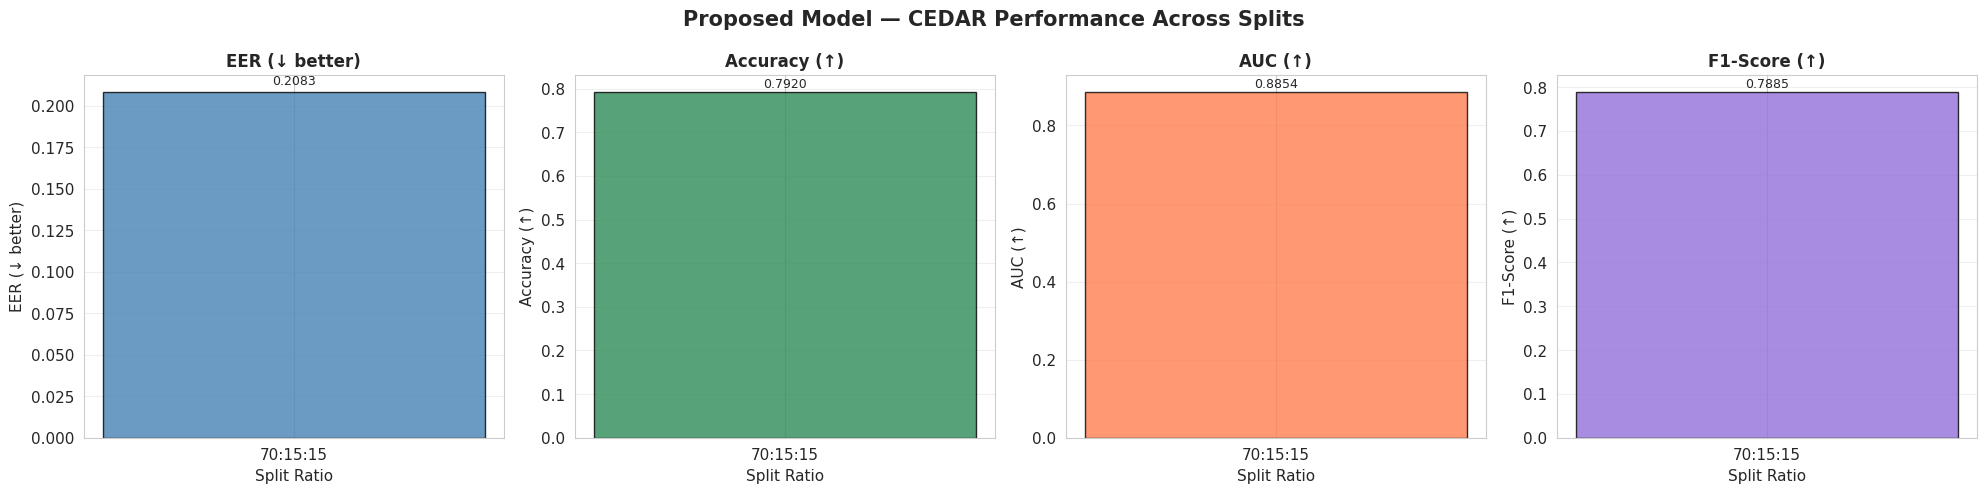

 > Plot saved to: /home/lawrence/workspace/thesis/thesis/checkpoints/proposed_splits/proposed_cedar_comparison.png


In [10]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle(f'Proposed Model — {DATASET_NAME} Performance Across Splits',
             fontsize=15, fontweight='bold')

metrics_to_plot = ['eer', 'accuracy', 'auc', 'f1']
titles          = ['EER (↓ better)', 'Accuracy (↑)', 'AUC (↑)', 'F1-Score (↑)']
colors          = ['steelblue', 'seagreen', 'coral', 'mediumpurple']

for ax, metric, title, color in zip(axes, metrics_to_plot, titles, colors):
    labels = []
    values = []
    for ratio in SPLIT_RATIOS:
        split_str = ratio.replace('_', ':')
        key       = f"{DATASET_NAME} ({split_str})"
        labels.append(split_str)
        values.append(all_results.get(key, {}).get(metric, 0))

    bars = ax.bar(labels, values, color=color, alpha=0.8, edgecolor='black')
    ax.set_xlabel('Split Ratio', fontsize=11)
    ax.set_ylabel(title, fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3, axis='y')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.003,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plot_path = os.path.join(CHECKPOINT_DIR, f'proposed_{DATASET}_comparison.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f" > Plot saved to: {plot_path}")